# Modellering av icke-linjär kreditfallissemangsrisk med regressionssplines

## Sammanfattning

Ett riskteam på en privatkundsbank behöver veta *var* fallissemangsrisken blir icke-linjär innan det binder sig vid ett scorekort i produktion. I stället för att i förväg binna varje variabel för hand anpassar teamet en **generaliserad additiv modell** med `PROC GAM`: varje låntagaregenskap går in som en kubisk utjämningsspline, så att tröskel- och U-formade samband skattas direkt från data på logit-skalan. På en avsiktligt ogynnsam syntetisk portfölj av 100 lån (39% fallissemang) minskar den additiva spline-modellen deviansen från 133.75 (endast intercept) till 61.69 — en minskning på 72.06 — för ett modell-AIC på 81.69. Den anpassade skuld-mot-inkomst-splinen bär den största koefficienten (4.34), och binning av det råa utfallet bekräftar den inbyggda strukturen: fallissemangsrisken är kraftigt **U-formad i ålder** (66.7% bland de yngsta låntagarna, 4.8% i medelåldern, 86.4% bland de äldsta) och driver uppåt med belåningsgrad.

## Datakällor

| Dataset | Rader | Roll | Nyckelvariabler | Beskrivning |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Modelleringsindata | `default` (0/1-målvariabel), `age`, `dti` (skuld mot inkomst), `utilization` (utnyttjande av revolverande kredit) | Syntetiska privatkundslåneansökningar. De sanna log-oddsen för fallissemang byggs med avsiktliga icke-lineariteter — en U-formad ålderseffekt och tröskelgångjärn i skuld mot inkomst och utnyttjande — och Bernoulli-samplas sedan. Genererade inline med `call streaminit(20260531)` och `rand()`; inga externa filer. |

Denna miljö körs utan licens, så utdata begränsas till 100 observationer. Scenariot är dimensionerat efter den gränsen: signalen görs tillräckligt stark för att en additiv spline-modell med tre termer ska kunna återskapa formerna från 100 lån.

# Varför splines för kreditrisk

Traditionella scorekort lutar sig mot logistisk regression med manuellt binnade variabler (weight-of-evidence / information-value). Det fungerar, men det tvingar analytikern att *gissa* var risktrösklarna och krökningen finns. En **generaliserad additiv modell (GAM)** ersätter varje linjär term med en jämn funktion — här en kubisk utjämningsspline med tre frihetsgrader — så att kurvformen skattas i stället för att antas. `PROC GAM` anpassar dessa jämna funktioner på logit-skalan för en binär målvariabel, precis miljön för en sannolikhet-för-fallissemang-modell.

I denna notebook spelar vi rollen som ett riskteam på en privatkundsbank. Vi:

1. Genererar en syntetisk låneportfölj vars **sanna** fallissemangssannolikhet är genuint icke-linjär (en U-formad ålderseffekt och tröskeleffekter i skuld mot inkomst och utnyttjande).
2. Anpassar en binomial/logit additiv spline-modell och läser av dess devians, AIC och koefficienter per jämn funktion.
3. Bekräftar de återskapade formerna genom att binna det råa fallissemangsutfallet och rita det med `PROC SGPLOT`.

Ingenting här kräver externa data eller en nätverksanslutning.

## Steg 1 - Bygg en syntetisk låneportfölj

Vi simulerar 100 låneansökningar. Varje låntagare har tre variabler. **Log-oddsen för fallissemang** konstrueras från avsiktligt icke-linjära komponenter så att vi har en känd grundsanning som spline-modellen kan återskapa:

- **Ålder** - en U-form: fallissemangsrisken är förhöjd för mycket unga och mycket gamla låntagare och lägst i medelåldern. Vi kodar detta som en kvadrerad, centrerad åldersterm.
- **DTI** - en tröskeleffekt: liten inverkan tills skuld mot inkomst passerar ~0.35, sedan stiger risken (ett ensidigt gångjärn).
- **Utnyttjande** - ett andra gångjärn vid ~0.60 av den revolverande kreditgränsen.

Den binära `default`-flaggan dras sedan från en Bernoullifördelning med den sannolikheten. Interceptet sätts tillräckligt lågt för att de inbyggda icke-lineariteterna, inte en hög baslinje, ska driva fallissemangen — detta är en avsiktligt ogynnsam högriskportfölj vald så att formerna är synliga i endast 100 lån.

In [1]:
data loans;
   CALL streaminit(20260531);

   GÖR id = 1 TILL 100;
      /* ---- låntagaregenskaper ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 år      */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* skuld/inkomst    */
      utilization = rand("UNIFORM");               /* 0 .. 1 av gräns  */

      /* ---- SANN icke-linjär log-odds för fallissemang ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-formad         */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* tröskelgångjärn  */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* tröskelgångjärn  */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      TA_BORT age_c eta_age eta_dti eta_util eta p_true;
      UTDATA;
   SLUT;
KÖR;

PROCEDUR MEDELVÄRDEN data=loans n mean MIN MAX maxdec=3;
   VARIABEL default AGE dti utilization;
   ETIKETT default="Fallissemang" AGE="Ålder"
         dti="Skuld/inkomst-kvot" utilization="Kreditutnyttjande";
KÖR;

                                                  The MEANS Procedure

 Variable     Label                      N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------------
 default      Fallissemang             100          0.390       0.000       1.000
 AGE          Ålder                    100         44.993      18.342      69.646
 dti          Skuld/inkomst-kvot       100          0.312       0.059       0.590
 utilization  Kreditutnyttjande        100          0.548       0.012       0.988
 --------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Sammanfattningen från `PROC MEANS` bekräftar portföljen: en övergripande fallissemangsfrekvens på **39%** (en stressad högriskbok), med ålder som spänner 18-70, skuld mot inkomst i genomsnitt 0.31, och utnyttjande i genomsnitt 0.55 över hela intervallet 0-1. Med data i handen kan vi anpassa modellen.

## Steg 2 - Anpassa den additiva spline-modellen

`MODEL`-satsen namnger den binära responsen och omsluter varje prediktor i `spline(var, df=3)`, vilket begär en kubisk utjämningsspline med tre frihetsgrader var. Alternativen:

- `event='1'` - modellera sannolikheten för *fallissemangs*-händelsen, inte icke-händelsen.
- `dist=binomial` - en 0/1-målvariabel anpassad på logit-skalan, det naturliga valet för en fallissemangssannolikhet.

`PROC GAM` rapporterar modellens **devians** och **AIC**, en koefficient för varje jämn term, och en tabell över utjämningsmodellen som listar antalet frihetsgrader som förbrukas per komponent.

In [2]:
TITEL "Generaliserad additiv logistisk modell för lånefallissemang";

PROCEDUR gam data=loans;
   MODEL default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
KÖR;

TITEL;

                              Generaliserad additiv logistisk modell för lånefallissemang                               


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Generaliserad additiv logistisk modell för lånefallissemang.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Anpassningen är stark. **Nulldeviansen** på 133.75 (en modell med endast intercept) faller till en residual-**devians på 61.69** när de tre jämna funktionerna läggs till — en minskning på 72.06 — och modellens **AIC är 81.69**. Bland de jämna termerna bär **skuld-mot-inkomst-splinen den största koefficienten (4.34)**, före ålders- och utnyttjande-splinerna, vilket identifierar belåningsgrad som den dominerande drivkraften bakom de anpassade log-oddsen. Varje jämn funktion förbrukar tre frihetsgrader, som begärt. Modellen har upptäckt att dessa samband är icke-linjära utan att vi specificerat en enda binn eller polynomterm.

## Steg 3 - Bekräfta de återskapade formerna

En anpassad jämn funktion är bara övertygande om den stämmer med rådata. Vi binnar varje låntagare efter ålder och efter skuld mot inkomst, beräknar den realiserade fallissemangsfrekvensen i varje band med `PROC MEANS`, och ritar den med `PROC SGPLOT`. Om spline-modellen talar sanning bör det binnade utfallet följa samma U-form och tröskel som modellen anpassade.

In [3]:
data binned;
   STÄLL_IN loans;
   LÄNGD dti_band $9 age_band $5;

   OM      dti < 0.20 SÅ dti_band = "0.00-0.20";
   ANNARS OM dti < 0.30 SÅ dti_band = "0.20-0.30";
   ANNARS OM dti < 0.40 SÅ dti_band = "0.30-0.40";
   ANNARS OM dti < 0.50 SÅ dti_band = "0.40-0.50";
   ANNARS                    dti_band = "0.50+";

   OM      AGE < 30 SÅ age_band = "18-30";
   ANNARS OM AGE < 40 SÅ age_band = "30-40";
   ANNARS OM AGE < 50 SÅ age_band = "40-50";
   ANNARS OM AGE < 60 SÅ age_band = "50-60";
   ANNARS                  age_band = "60-70";
KÖR;

PROCEDUR MEDELVÄRDEN data=binned NWAY NOPRINT;
   KLASS age_band;
   VARIABEL default;
   UTDATA out=age_rate(TA_BORT=_type_ _freq_)
          n=n mean(default)=def_rate;
KÖR;

PROCEDUR MEDELVÄRDEN data=binned NWAY NOPRINT;
   KLASS dti_band;
   VARIABEL default;
   UTDATA out=dti_rate(TA_BORT=_type_ _freq_)
          n=n mean(default)=def_rate;
KÖR;

PROCEDUR SKRIV data=age_rate noobs ETIKETT;
   VARIABEL age_band n def_rate;
   ETIKETT age_band="Åldersintervall" n="Konton" def_rate="Fallissemangsgrad";
   format def_rate percent8.1;
KÖR;

PROCEDUR SKRIV data=dti_rate noobs ETIKETT;
   VARIABEL dti_band n def_rate;
   ETIKETT dti_band="Skuld/inkomst-intervall" n="Konton"
         def_rate="Fallissemangsgrad";
   format def_rate percent8.1;
KÖR;


 Åldersintervall  Konton  Fallissemangsgrad
----------------  ------  -----------------
18-30                 21              66.7%
30-40                 19              10.5%
40-50                 21               4.8%
50-60                 17              17.6%
60-70                 22              86.4%

Skuld/inkomst-intervall  Konton  Fallissemangsgrad
-----------------------  ------  -----------------
0.00-0.20                    29              37.9%
0.20-0.30                    21              28.6%
0.30-0.40                    15              33.3%
0.40-0.50                    20              50.0%
0.50+                        15              46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Åldersbanden följer ett tydligt U: **66.7%** av låntagarna under 30 fick fallissemang, frekvensen bottnar vid **4.8%** för bandet 40-50, och klättrar sedan tillbaka till **86.4%** för låntagare 60 och äldre. Skuld-mot-inkomst-banden driver uppåt överlag — från den höga 30-procentsnivån i det lägsta bandet till ungefär 50% bortom en DTI på 0.40 — men med endast 100 lån är frekvenserna per band brusiga, vilket är precis varför modellens jämna funktion (snarare än en enda hård gräns) är den mer tillförlitliga sammanfattningen. Diagrammen nedan gör båda formerna synliga.

### Ålderseffekten är U-formad

Att rita den realiserade fallissemangsfrekvensen per åldersband visar den krökning som splinen återskapade: hög risk i båda ändarna av åldersintervallet, en djup svacka i medelåldern.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


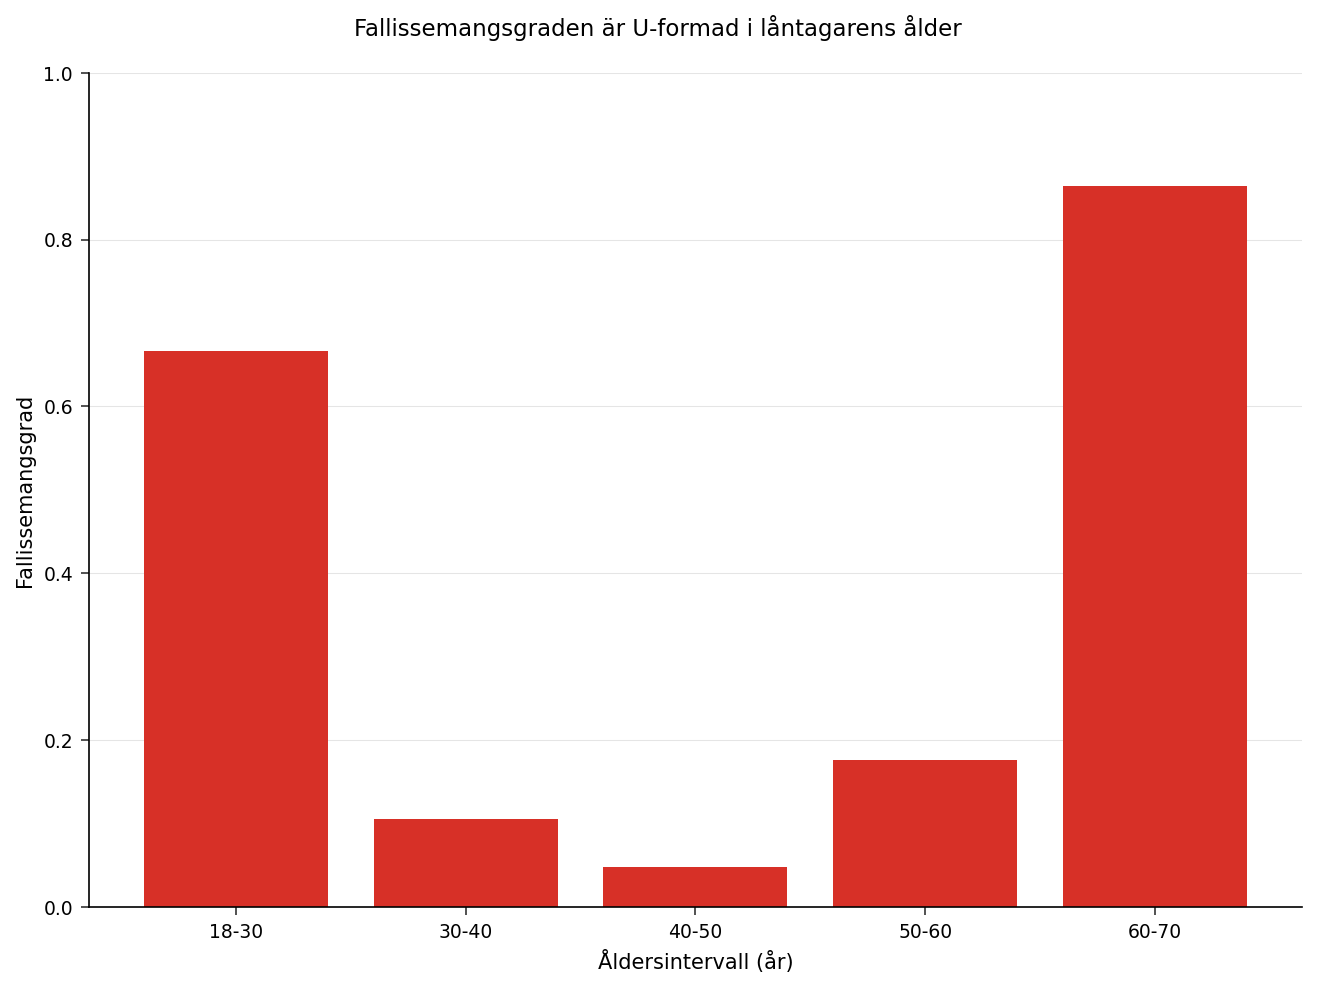

In [4]:
ODS GRAPHICS ON;

PROCEDUR SGPLOT data=age_rate noautolegend;
   TITEL "Fallissemangsgraden är U-formad i låntagarens ålder";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ETIKETT="Fallissemangsgrad" VALUES=(0 TILL 1 EFTER 0.2) grid;
   XAXIS ETIKETT="Åldersintervall (år)";
KÖR;

TITEL;
ODS GRAPHICS OFF;

### Risken driver uppåt med belåningsgrad

Skuld-mot-inkomst-banden trendar uppåt — de mest belånade låntagarna får oftast fallissemang — förenligt med den dominerande DTI-splinen i modellen. Mittbanden är brusiga vid denna urvalsstorlek, vilket understryker varför den anpassade splinen är en stadigare vägledning än någon enskild handritad gräns.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


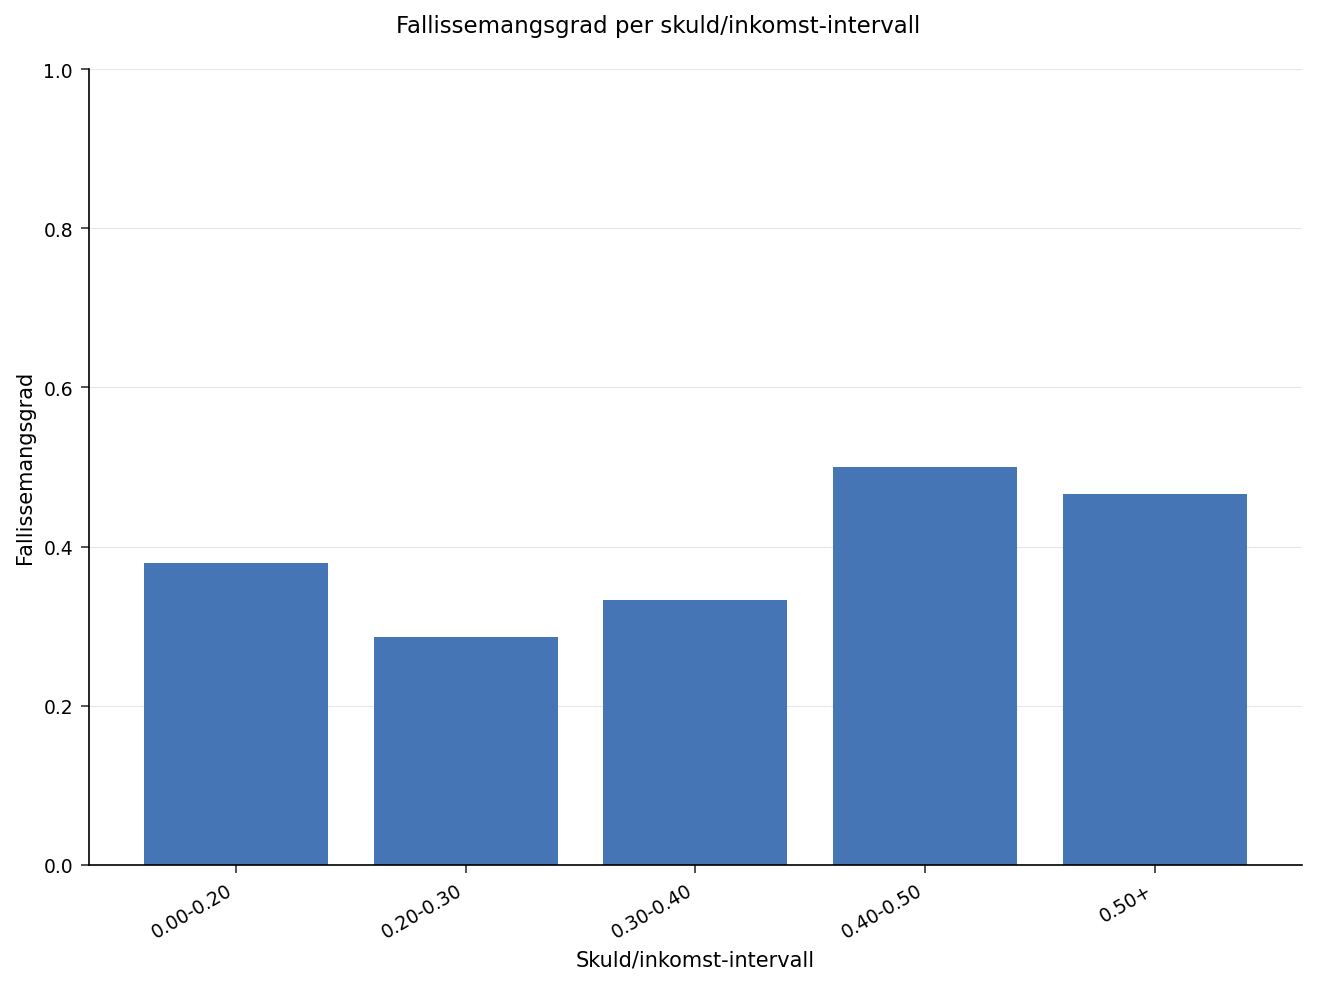

In [5]:
ODS GRAPHICS ON;

PROCEDUR SGPLOT data=dti_rate noautolegend;
   TITEL "Fallissemangsgrad per skuld/inkomst-intervall";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ETIKETT="Fallissemangsgrad" VALUES=(0 TILL 1 EFTER 0.2) grid;
   XAXIS ETIKETT="Skuld/inkomst-intervall";
KÖR;

TITEL;
ODS GRAPHICS OFF;

## Tolkning av resultaten

`PROC GAM` återskapade den icke-linjära struktur vi byggde in i den syntetiska portföljen utan någon manuell binning eller polynomtermer:

- **Stark övergripande anpassning** - den additiva spline-modellen driver deviansen från 133.75 ner till 61.69 (en minskning på 72.06) för ett modell-AIC på 81.69, på en bok med en 39-procentig bas-fallissemangsfrekvens.
- **Belåningsgrad dominerar** - skuld-mot-inkomst-splinen bär den största koefficienten (4.34) av de tre termerna, vilket pekar ut DTI som den ledande drivkraften bakom de anpassade log-oddsen.
- **Krökning i ålder** - binning av det råa utfallet bekräftar ett läroboks-U: 66.7% fallissemang i bandet under 30, en svacka på 4.8% vid 40-50, och 86.4% för bandet 60 och äldre — den form som en kubisk spline fångar naturligt men som en enda linjär åldersterm skulle missa helt.
- **Ärlig om brus** - vid 100 lån vacklar skuld-mot-inkomst-frekvenserna per band, vilket är precis argumentet för en jämn skattning framför en hård handvald gräns.

**Varför detta spelar roll för bankverksamhet:** additiva splines ger ett riskteam ett snabbt, automatiskt sätt att upptäcka var ett samband är genuint icke-linjärt innan man binder sig vid ett scorekort i produktion. De anpassade jämna funktionerna är direkt tolkbara som riskkurvor — en ålderspremie för unga och gamla, en belåningsramp — och deviansen och AIC:n kvantifierar hur mycket den flexibiliteten ger jämfört med en platt linjär modell.